In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from collections import Counter

df = pd.read_csv('../data/raw/creditcard.csv')
print(f"Shape: {df.shape}")
print(df.head(3))

Shape: (284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   

        V26       V27       V28  Amount  Class  
0 -0.189115  0.133558 -0.021053  149.62      0  
1  0.125895 -0.008983  0.014724    2.69      0  
2 -0.139097 -0.055353 -0.059752  378.66      0  

[3 rows x 31 columns]


In [2]:
from sklearn.model_selection import train_test_split
import os

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          
)

print(f"Train size: {X_train.shape}  |  Fraud in train: {y_train.sum()} ({y_train.mean()*100:.3f}%)")
print(f"Test size:  {X_test.shape}   |  Fraud in test:  {y_test.sum()} ({y_test.mean()*100:.3f}%)")

os.makedirs('../data/processed', exist_ok=True)

X_train.to_csv('../data/processed/X_train_raw.csv', index=False)
X_test.to_csv('../data/processed/X_test_raw.csv', index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

print("Splits saved successfully in ../data/processed/")

Train size: (227845, 30)  |  Fraud in train: 394 (0.173%)
Test size:  (56962, 30)   |  Fraud in test:  98 (0.172%)
Splits saved successfully in ../data/processed/


In [3]:
def engineer_features(X):
    X = X.copy()
    
    # 1. Time → hour of day
    X['hour'] = (X['Time'] % 86400) / 3600
    
    # 2. Night flag (fraud spikes late night / early morning)
    X['is_night'] = ((X['hour'] < 6) | (X['hour'] > 22)).astype(int)
    
    # 3. Log-transform Amount (heavy right skew)
    X['log_amount'] = np.log1p(X['Amount'])
    
    # 4. Amount buckets (small=card testing, large=cashout)
    X['amount_bin'] = pd.cut(
        X['Amount'],
        bins=[-1, 1, 10, 100, 500, np.inf],
        labels=[0, 1, 2, 3, 4]
    ).astype(int)
    
    # 5. Interaction: high-signal features × log_amount
    # V14 and V17 are top predictors from EDA
    X['v14_x_amount'] = X['V14'] * X['log_amount']
    X['v17_x_amount'] = X['V17'] * X['log_amount']
    X['v12_x_amount'] = X['V12'] * X['log_amount']
    
    # 6. Drop raw Time and Amount (replaced by derived features)
    X = X.drop(columns=['Time', 'Amount'])
    
    return X

X_train_eng = engineer_features(X_train)
X_test_eng  = engineer_features(X_test)

print(f"Features before: {X_train.shape[1]}")
print(f"Features after:  {X_train_eng.shape[1]}")
print(f"\nNew features: {[c for c in X_train_eng.columns if c not in X_train.columns]}")

Features before: 30
Features after:  35

New features: ['hour', 'is_night', 'log_amount', 'amount_bin', 'v14_x_amount', 'v17_x_amount', 'v12_x_amount']


In [4]:
# RobustScaler: uses median and IQR — not affected by outliers
# CRITICAL: fit on train, transform both train and test

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_eng)
X_test_scaled  = scaler.transform(X_test_eng)   # ← transform only, never fit

print(f"Scaled train shape: {X_train_scaled.shape}")
print(f"Scaled test shape:  {X_test_scaled.shape}")

# Quick sanity check — mean should be ~0, std ~1
df_check = pd.DataFrame(X_train_scaled, columns=X_train_eng.columns)
print(f"\nMean of scaled features (should be ~0):\n{df_check.mean().round(3).head(6)}")
print(f"\nStd of scaled features (should be ~1):\n{df_check.std().round(3).head(6)}")

Scaled train shape: (227845, 35)
Scaled test shape:  (56962, 35)

Mean of scaled features (should be ~0):
V1   -0.008
V2   -0.047
V3   -0.094
V4    0.013
V5    0.042
V6    0.234
dtype: float64

Std of scaled features (should be ~1):
V1    0.876
V2    1.176
V3    0.790
V4    0.891
V5    1.058
V6    1.142
dtype: float64


In [5]:
print(f"Before SMOTE: {Counter(y_train)}")
print(f"Fraud ratio:  {y_train.mean()*100:.3f}%")

# Apply SMOTE ONLY to training data — NEVER to test
# sampling_strategy=0.1 means fraud becomes 10% of majority class
# (don't go to 50/50 — too artificial, hurts real-world performance)
sm = SMOTE(random_state=42, sampling_strategy=0.1)
X_train_sm, y_train_sm = sm.fit_resample(X_train_scaled, y_train)

print(f"\nAfter SMOTE:  {Counter(y_train_sm)}")
print(f"Fraud ratio:  {y_train_sm.mean()*100:.3f}%")
print(f"New train size: {X_train_sm.shape[0]:,}")

Before SMOTE: Counter({0: 227451, 1: 394})
Fraud ratio:  0.173%

After SMOTE:  Counter({0: 227451, 1: 22745})
Fraud ratio:  9.091%
New train size: 250,196


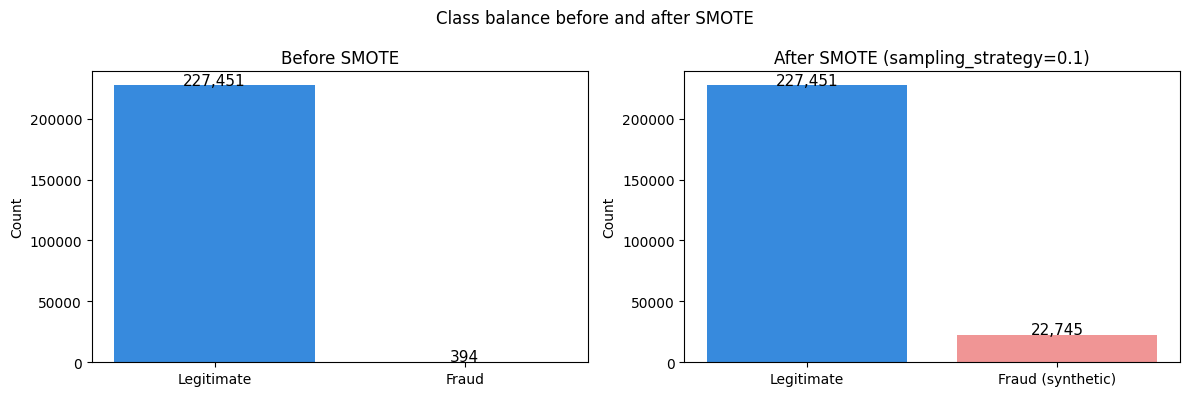

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before
axes[0].bar(['Legitimate', 'Fraud'], 
            [Counter(y_train)[0], Counter(y_train)[1]],
            color=['#378ADD', '#E24B4A'])
axes[0].set_title('Before SMOTE')
axes[0].set_ylabel('Count')
for i, v in enumerate([Counter(y_train)[0], Counter(y_train)[1]]):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=11)

# After
axes[1].bar(['Legitimate', 'Fraud (synthetic)'], 
            [Counter(y_train_sm)[0], Counter(y_train_sm)[1]],
            color=['#378ADD', '#F09595'])
axes[1].set_title('After SMOTE (sampling_strategy=0.1)')
axes[1].set_ylabel('Count')
for i, v in enumerate([Counter(y_train_sm)[0], Counter(y_train_sm)[1]]):
    axes[1].text(i, v + 500, f'{v:,}', ha='center', fontsize=11)

plt.suptitle('Class balance before and after SMOTE')
plt.tight_layout()
plt.savefig('../notebooks/figures/smote_comparison.png', dpi=150)
plt.show()

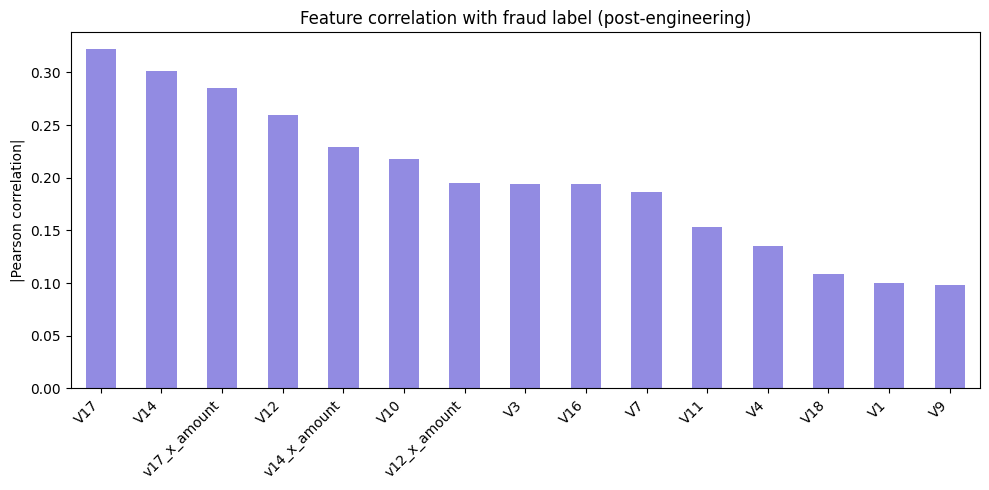

Top 10 features:
 V17             0.321937
V14             0.301054
v17_x_amount    0.285523
V12             0.259989
v14_x_amount    0.229341
V10             0.217894
v12_x_amount    0.195048
V3              0.194135
V16             0.193826
V7              0.186184
Name: Class, dtype: float64


In [7]:
df_train_check = pd.DataFrame(X_train_scaled, columns=X_train_eng.columns)
df_train_check['Class'] = y_train.values

corr_with_fraud = df_train_check.corr()['Class'].drop('Class').abs().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
corr_with_fraud.head(15).plot(kind='bar', color='#7F77DD', alpha=0.85)
plt.title('Feature correlation with fraud label (post-engineering)')
plt.ylabel('|Pearson correlation|')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../notebooks/figures/feature_correlation_post_eng.png', dpi=150)
plt.show()

print("Top 10 features:\n", corr_with_fraud.head(10))

In [8]:
import joblib

# Save scaled arrays
np.save('../data/processed/X_train_scaled.npy', X_train_scaled)
np.save('../data/processed/X_test_scaled.npy',  X_test_scaled)
np.save('../data/processed/X_train_sm.npy',     X_train_sm)
np.save('../data/processed/y_train_sm.npy',     y_train_sm)
np.save('../data/processed/y_test.npy',         y_test.values)

# Save scaler so inference uses the same transform
joblib.dump(scaler, '../data/processed/scaler.pkl')

# Save feature names for SHAP later
feature_names = X_train_eng.columns.tolist()
pd.Series(feature_names).to_csv('../data/processed/feature_names.csv', index=False)

print("Saved:")
print("  ../data/processed/X_train_scaled.npy")
print("  ../data/processed/X_test_scaled.npy")
print("  ../data/processed/X_train_sm.npy  (SMOTE-balanced training set)")
print("  ../data/processed/y_train_sm.npy")
print("  ../data/processed/y_test.npy")
print("  ../data/processed/scaler.pkl")
print("  ../data/processed/feature_names.csv")

Saved:
  ../data/processed/X_train_scaled.npy
  ../data/processed/X_test_scaled.npy
  ../data/processed/X_train_sm.npy  (SMOTE-balanced training set)
  ../data/processed/y_train_sm.npy
  ../data/processed/y_test.npy
  ../data/processed/scaler.pkl
  ../data/processed/feature_names.csv
